# BigQuery Cost Observability

## Loading Data

In [117]:
import pandas as pd

In [118]:
import matplotlib.pyplot as plt

In [119]:
url = 'https://raw.githubusercontent.com/gitleolopes/python_projects/refs/heads/main/bigquery_cost_observability/data/bigquery_jobs_2025_mock_sample.csv'

In [120]:
bigquery_jobs = pd.read_csv(url, delimiter = ',')
bigquery_jobs.head()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state
0,job_000001,user_011@company.com,project_36,2025-11-16 08:42:39,2025-11-16 08:42:43,2025-11-16 08:48:57,QUERY,SELECT,SELECT * FROM sales.transactions,552784715,552784715,142494,False,DONE
1,job_000002,user_032@company.com,project_36,2025-05-08 16:47:46,2025-05-08 16:47:51,2025-05-08 16:49:31,QUERY,SELECT,"SELECT id, created_at FROM users.p...",494116970,494116970,29100,False,DONE
2,job_000003,user_013@company.com,project_48,2025-01-22 18:05:14,2025-01-22 18:05:15,2025-01-22 18:12:05,QUERY,SELECT,SELECT * FROM sales.transactions,2676313420,2676313420,159490,False,DONE
3,job_000004,user_005@company.com,project_23,2025-12-18 09:57:24,2025-12-18 09:57:25,2025-12-18 10:01:49,QUERY,SELECT,SELECT * FROM events.sessions,88754095,88754095,121968,False,DONE
4,job_000005,user_073@company.com,project_41,2025-12-26 10:06:44,2025-12-26 10:06:47,2025-12-26 10:08:07,QUERY,SELECT,"SELECT id, created_at FROM users.p...",4748282422,4748282422,17680,False,DONE


## Data Profiling

In [121]:
bigquery_jobs.head()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state
0,job_000001,user_011@company.com,project_36,2025-11-16 08:42:39,2025-11-16 08:42:43,2025-11-16 08:48:57,QUERY,SELECT,SELECT * FROM sales.transactions,552784715,552784715,142494,False,DONE
1,job_000002,user_032@company.com,project_36,2025-05-08 16:47:46,2025-05-08 16:47:51,2025-05-08 16:49:31,QUERY,SELECT,"SELECT id, created_at FROM users.p...",494116970,494116970,29100,False,DONE
2,job_000003,user_013@company.com,project_48,2025-01-22 18:05:14,2025-01-22 18:05:15,2025-01-22 18:12:05,QUERY,SELECT,SELECT * FROM sales.transactions,2676313420,2676313420,159490,False,DONE
3,job_000004,user_005@company.com,project_23,2025-12-18 09:57:24,2025-12-18 09:57:25,2025-12-18 10:01:49,QUERY,SELECT,SELECT * FROM events.sessions,88754095,88754095,121968,False,DONE
4,job_000005,user_073@company.com,project_41,2025-12-26 10:06:44,2025-12-26 10:06:47,2025-12-26 10:08:07,QUERY,SELECT,"SELECT id, created_at FROM users.p...",4748282422,4748282422,17680,False,DONE


In [122]:
bigquery_jobs.tail()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state
79995,job_079996,user_008@company.com,project_37,2025-07-26 23:52:07,2025-07-26 23:52:09,2025-07-27 00:01:30,QUERY,SELECT,"SELECT id, created_at FROM analyti...",78107304,0,145299,True,DONE
79996,job_079997,user_081@company.com,project_41,2025-06-25 14:15:11,2025-06-25 14:15:14,2025-06-25 14:17:18,QUERY,SELECT,"SELECT id, created_at FROM sales.t...",63055802,0,7316,True,DONE
79997,job_079998,user_100@company.com,project_03,2025-12-15 02:24:40,2025-12-15 02:24:43,2025-12-15 02:33:53,QUERY,INSERT,INSERT INTO sales.transactions SELECT * FROM s...,1776942930,1776942930,149600,False,DONE
79998,job_079999,user_025@company.com,project_01,2025-06-04 15:14:40,2025-06-04 15:14:40,2025-06-04 15:17:52,QUERY,INSERT,INSERT INTO users.profile SELECT * FROM stagin...,306259168,306259168,18432,False,DONE
79999,job_080000,user_089@company.com,project_48,2025-03-10 12:03:17,2025-03-10 12:03:18,2025-03-10 12:08:55,QUERY,SELECT,"SELECT id, created_at FROM analyti...",48027637,48027637,39766,False,DONE


In [123]:
bigquery_jobs.shape

(80000, 14)

In [124]:
bigquery_jobs.columns

Index(['job_id', 'user_email', 'project_id', 'creation_time', 'start_time',
       'end_time', 'job_type', 'statement_type', 'query',
       'total_bytes_processed', 'total_bytes_billed', 'slot_ms', 'cache_hit',
       'state'],
      dtype='object')

In [125]:
bigquery_jobs.dtypes

,0
job_id,object
user_email,object
project_id,object
creation_time,object
start_time,object
end_time,object
job_type,object
statement_type,object
query,object
total_bytes_processed,int64


In [126]:
bigquery_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   job_id                 80000 non-null  object
 1   user_email             80000 non-null  object
 2   project_id             80000 non-null  object
 3   creation_time          80000 non-null  object
 4   start_time             80000 non-null  object
 5   end_time               80000 non-null  object
 6   job_type               80000 non-null  object
 7   statement_type         80000 non-null  object
 8   query                  80000 non-null  object
 9   total_bytes_processed  80000 non-null  int64 
 10  total_bytes_billed     80000 non-null  int64 
 11  slot_ms                80000 non-null  int64 
 12  cache_hit              80000 non-null  bool  
 13  state                  80000 non-null  object
dtypes: bool(1), int64(3), object(10)
memory usage: 8.0+ MB


## Data Type Standardization

In [127]:
bigquery_jobs['creation_time'] = pd.to_datetime(bigquery_jobs['creation_time'])
bigquery_jobs['start_time'] = pd.to_datetime(bigquery_jobs['start_time'])
bigquery_jobs['end_time'] = pd.to_datetime(bigquery_jobs['end_time'])

In [128]:
bigquery_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_id                 80000 non-null  object        
 1   user_email             80000 non-null  object        
 2   project_id             80000 non-null  object        
 3   creation_time          80000 non-null  datetime64[ns]
 4   start_time             80000 non-null  datetime64[ns]
 5   end_time               80000 non-null  datetime64[ns]
 6   job_type               80000 non-null  object        
 7   statement_type         80000 non-null  object        
 8   query                  80000 non-null  object        
 9   total_bytes_processed  80000 non-null  int64         
 10  total_bytes_billed     80000 non-null  int64         
 11  slot_ms                80000 non-null  int64         
 12  cache_hit              80000 non-null  bool          
 13  s

## Data Quality

In [129]:
bigquery_jobs.job_id.nunique()

80000

In [130]:
bigquery_jobs.job_id.duplicated().sum()

np.int64(0)

In [131]:
bigquery_jobs.isnull().sum()

,0
job_id,0
user_email,0
project_id,0
creation_time,0
start_time,0
end_time,0
job_type,0
statement_type,0
query,0
total_bytes_processed,0


In [132]:
bigquery_jobs.query('creation_time > start_time')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [133]:
bigquery_jobs.query('start_time > end_time')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [134]:
bigquery_jobs.query('total_bytes_processed <= 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [135]:
bigquery_jobs.query('total_bytes_billed < 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [136]:
bigquery_jobs.query('slot_ms <= 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [137]:
bigquery_jobs.query('total_bytes_billed > total_bytes_processed')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [138]:
bigquery_jobs.query('cache_hit == True and total_bytes_billed != 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


## Data Transformation

In [139]:
bigquery_jobs['creation_month'] = bigquery_jobs['creation_time'].dt.to_period('M')

In [140]:
bigquery_jobs['total_tbytes_processed'] = bigquery_jobs['total_bytes_processed']*50/(1024**4)

In [141]:
bigquery_jobs['duration'] = (bigquery_jobs['end_time'] - bigquery_jobs['start_time']).dt.total_seconds()

In [142]:
bigquery_jobs.statement_type.unique()

array(['SELECT', 'UPDATE', 'INSERT', 'SCRIPT', 'DELETE'], dtype=object)

In [143]:
bigquery_jobs.statement_type.value_counts()

,count
statement_type,
SELECT,48127
INSERT,12002
SCRIPT,8017
UPDATE,7912
DELETE,3942


In [144]:
bigquery_jobs_wout_script = bigquery_jobs.query('statement_type != "SCRIPT"')

In [145]:
bigquery_jobs_wout_script.statement_type.value_counts()

,count
statement_type,
SELECT,48127
INSERT,12002
UPDATE,7912
DELETE,3942


In [146]:
bigquery_jobs_wout_script.head()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state,creation_month,total_tbytes_processed,duration
0,job_000001,user_011@company.com,project_36,2025-11-16 08:42:39,2025-11-16 08:42:43,2025-11-16 08:48:57,QUERY,SELECT,SELECT * FROM sales.transactions,552784715,552784715,142494,False,DONE,2025-11,0.025138,374.0
1,job_000002,user_032@company.com,project_36,2025-05-08 16:47:46,2025-05-08 16:47:51,2025-05-08 16:49:31,QUERY,SELECT,"SELECT id, created_at FROM users.p...",494116970,494116970,29100,False,DONE,2025-05,0.022470,100.0
2,job_000003,user_013@company.com,project_48,2025-01-22 18:05:14,2025-01-22 18:05:15,2025-01-22 18:12:05,QUERY,SELECT,SELECT * FROM sales.transactions,2676313420,2676313420,159490,False,DONE,2025-01,0.121705,410.0
3,job_000004,user_005@company.com,project_23,2025-12-18 09:57:24,2025-12-18 09:57:25,2025-12-18 10:01:49,QUERY,SELECT,SELECT * FROM events.sessions,88754095,88754095,121968,False,DONE,2025-12,0.004036,264.0
4,job_000005,user_073@company.com,project_41,2025-12-26 10:06:44,2025-12-26 10:06:47,2025-12-26 10:08:07,QUERY,SELECT,"SELECT id, created_at FROM users.p...",4748282422,4748282422,17680,False,DONE,2025-12,0.215927,80.0


## Analysis

### Processing per Month

**Why are we analyzing this?**

This analysis can help us understand BigQuery usage over an entire year, identifying periods of high and low processing.

In [147]:
bq_month_tbytes_processed = bigquery_jobs_wout_script[['creation_month', 'total_tbytes_processed']]
bq_month_tbytes_processed.head()

,creation_month,total_tbytes_processed
0,2025-11,0.025138
1,2025-05,0.022470
2,2025-01,0.121705
3,2025-12,0.004036
4,2025-12,0.215927


In [164]:
bq_month_tbytes_processed = bq_month_tbytes_processed.groupby('creation_month').sum('total_tbytes_processed').sort_values('creation_month').reset_index()
bq_month_tbytes_processed.head()

,creation_month,total_tbytes_processed
0,2025-01,273.786068
1,2025-02,243.973117
2,2025-03,286.281714
3,2025-04,273.617639
4,2025-05,274.998884


<Axes: title={'center': 'Processing per Month'}, xlabel='creation_month', ylabel='Tbytes Processed'>

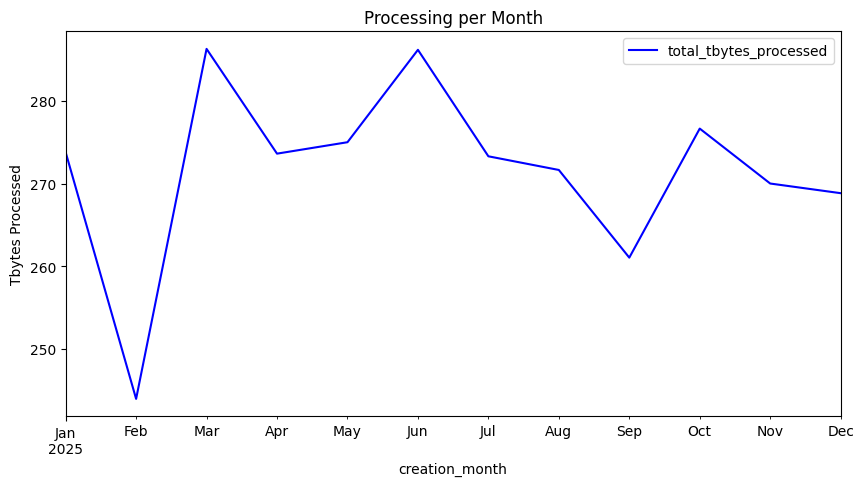

In [149]:
bq_month_tbytes_processed.plot(kind = 'line'
                            ,figsize = (10, 5)
                            ,x = 'creation_month'
                            ,y = 'total_tbytes_processed'
                            ,color = 'blue'
                            ,title = 'Processing per Month'
                            ,xlabel='creation_month'
                            ,ylabel = 'Tbytes Processed')

**What did we find?**

BigQuery processing volume remained relatively stable throughout 2025, with monthly consumption generally ranging between 243 and 286 TB. February recorded the lowest processing volume at approximately 243 TB, while March and June recorded the highest monthly volume at approximately 286 TB.

Overall, the data does not indicate a strong upward or downward trend in processing consumption throughout the year.

### Processing per Project

**Why are we analysing this?**

Identifying the projects with the highest processing volume can help us take action with the manager responsible for those projects.

In [150]:
bq_project_tbytes_processed = bigquery_jobs_wout_script[['project_id', 'total_tbytes_processed']]
bq_project_tbytes_processed.head()

,project_id,total_tbytes_processed
0,project_36,0.025138
1,project_36,0.022470
2,project_48,0.121705
3,project_23,0.004036
4,project_41,0.215927


In [151]:
bq_project_tbytes_processed = bq_project_tbytes_processed.groupby('project_id').sum('total_tbytes_processed').sort_values('total_tbytes_processed', ascending = True).reset_index()
bq_project_tbytes_processed.head()

,project_id,total_tbytes_processed
0,project_03,60.496889
1,project_20,61.682536
2,project_22,61.753903
3,project_05,61.891518
4,project_15,61.920148


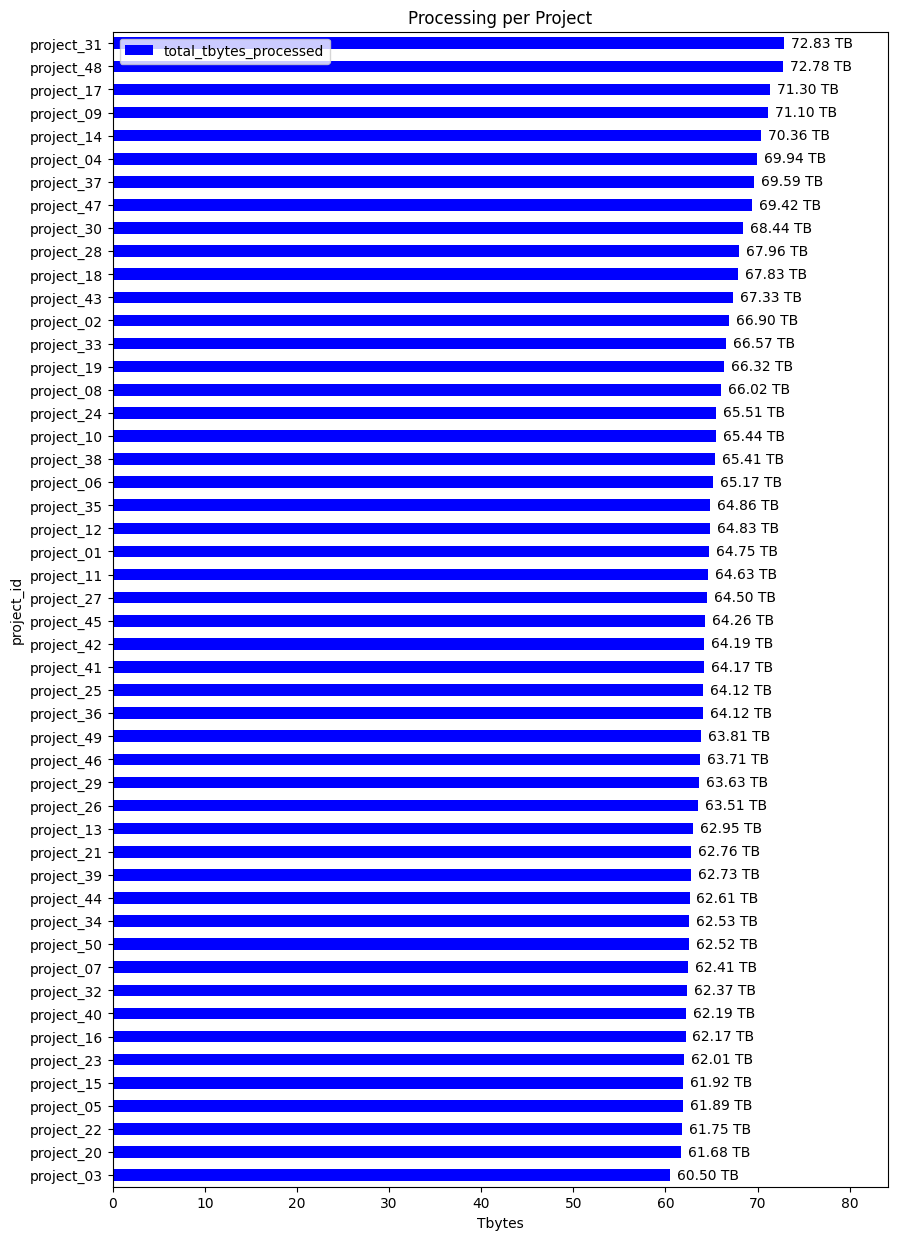

In [152]:
ax =bq_project_tbytes_processed.plot(kind='barh'
                                  ,x = 'project_id'
                                  ,y='total_tbytes_processed'
                                  ,figsize = (10, 15)
                                  ,color = 'blue'
                                  ,title = 'Processing per Project'
                                  ,ylabel='project_id'
                                  ,xlabel='Tbytes')
ax.bar_label(ax.containers[0], fmt='%.2f TB', padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
plt.show()

In [153]:
bq_project_processed_expensive = bq_project_tbytes_processed.tail(10)
bq_project_processed_expensive

,project_id,total_tbytes_processed
40,project_28,67.958009
41,project_30,68.440289
42,project_47,69.421570
43,project_37,69.590817
44,project_04,69.943567
45,project_14,70.358573
46,project_09,71.101675
47,project_17,71.300891
48,project_48,72.781942
49,project_31,72.825550


<Axes: title={'center': 'Tbyes Processed per Project'}, xlabel='total_tbytes_processed', ylabel='project_id'>

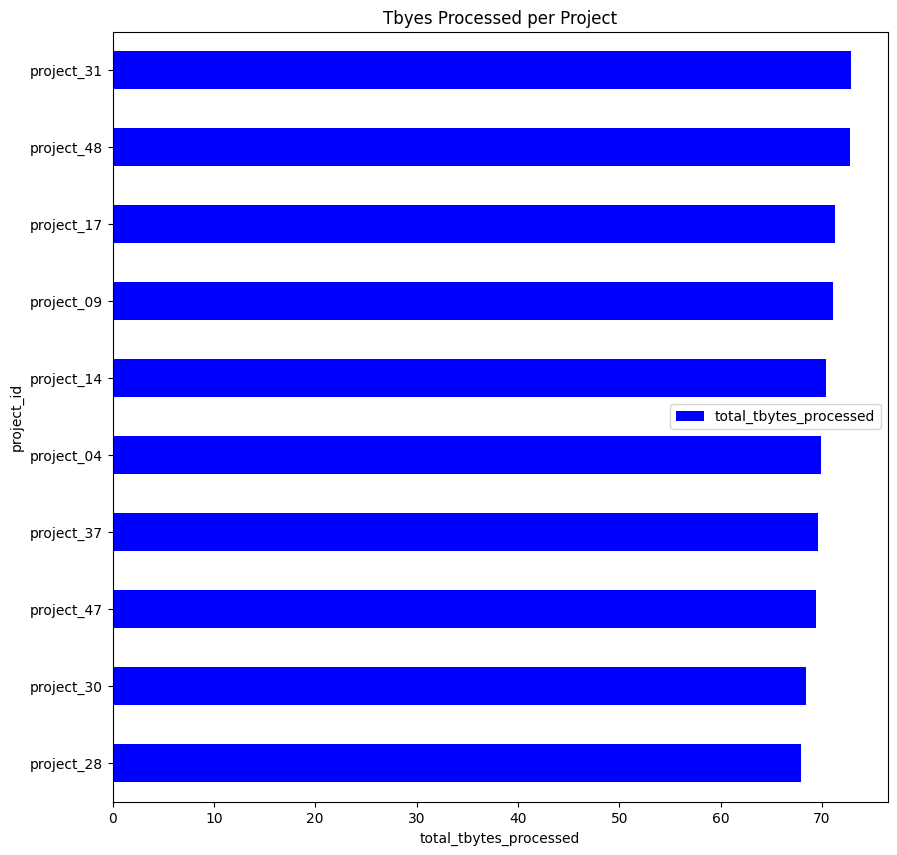

In [154]:
bq_project_processed_expensive.plot(kind = 'barh'
                          ,figsize = (10, 10)
                          ,x = 'project_id'
                          ,y = 'total_tbytes_processed'
                          ,ylabel = 'project_id'
                          ,xlabel = 'total_tbytes_processed'
                          ,color = 'blue'
                          ,title = 'Tbyes Processed per Project')

**What did we find?**

Processing volume is relatively evenly distributed across projects, with no project showing a significantly higher processing volume than the others.

The projects with the highest processing volumes could be prioritized for further investigation. Engaging with the managers responsible for these projects could help identify potential optimization opportunities.

### Processing per User

In [155]:
bq_user_tbytes_processed = bigquery_jobs_wout_script[['user_email', 'total_tbytes_processed']]

In [156]:
bq_user_tbytes_processed = bq_user_tbytes_processed.groupby('user_email').sum('total_tbytes_processed').sort_values('total_tbytes_processed', ascending = True).reset_index()
bq_user_tbytes_processed.head()

,user_email,total_tbytes_processed
0,user_076@company.com,27.581840
1,user_075@company.com,28.047054
2,user_004@company.com,28.411530
3,user_002@company.com,28.424531
4,user_068@company.com,28.899757


<Axes: title={'center': 'Processing per User'}, xlabel='Tbytes Processed', ylabel='user_email'>

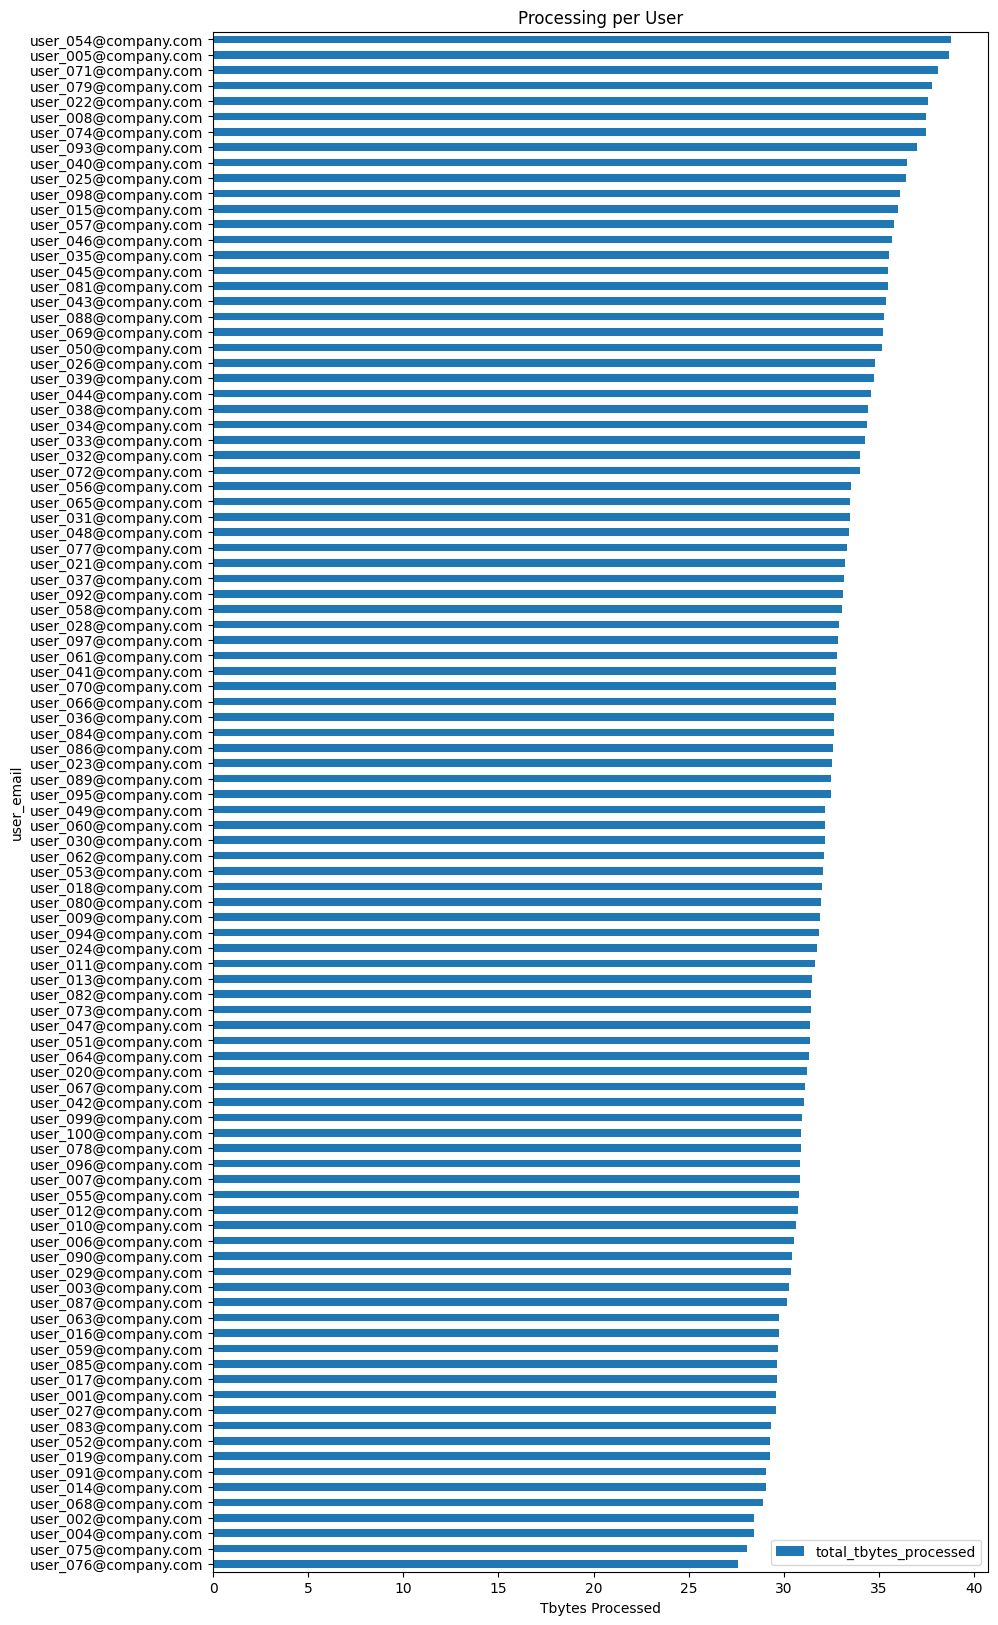

In [157]:
bq_user_tbytes_processed.plot(kind = 'barh'
                              ,figsize = (10,20)
                              ,x = 'user_email'
                              ,y = 'total_tbytes_processed'
                              ,title = 'Processing per User'
                              ,ylabel='user_email'
                              ,xlabel = 'Tbytes Processed')

In [158]:
bq_users_processed_expensive = bq_user_tbytes_processed.tail(10)
bq_users_processed_expensive

,user_email,total_tbytes_processed
90,user_025@company.com,36.395496
91,user_040@company.com,36.469265
92,user_093@company.com,36.976999
93,user_074@company.com,37.455642
94,user_008@company.com,37.469511
95,user_022@company.com,37.544997
96,user_079@company.com,37.800352
97,user_071@company.com,38.083742
98,user_005@company.com,38.649155
99,user_054@company.com,38.785109


<Axes: ylabel='user_email'>

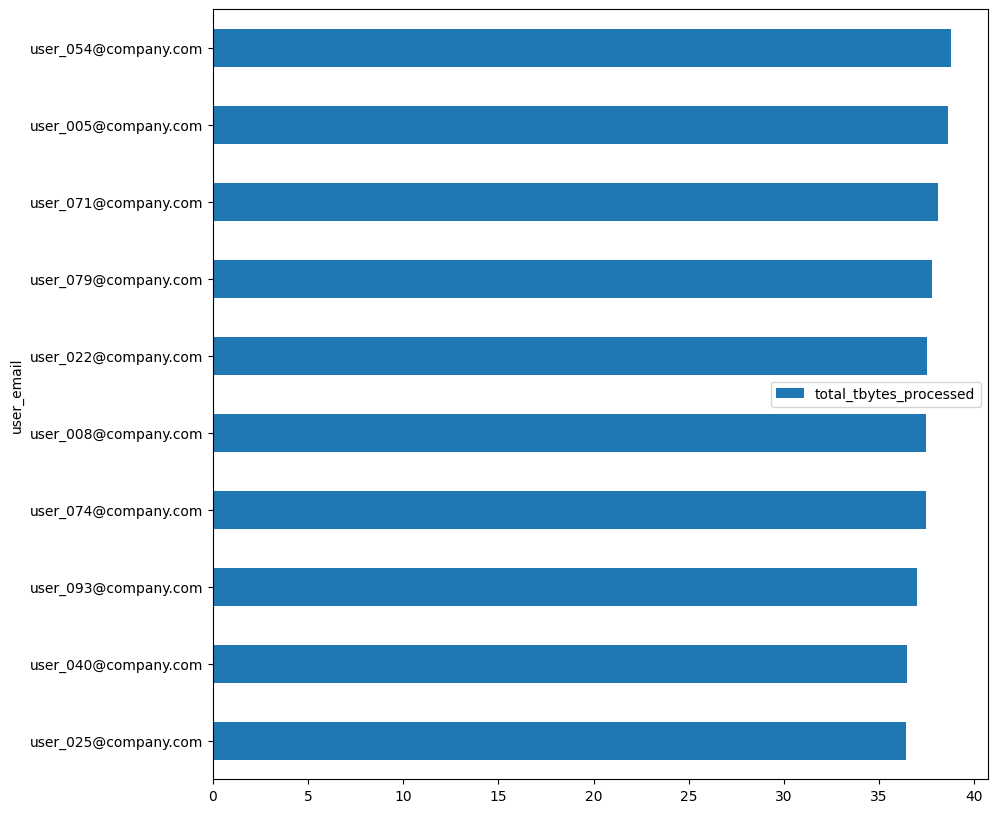

In [159]:
bq_users_processed_expensive.plot(kind = 'barh'
                                  ,figsize = (10,10)
                                  ,x = 'user_email'
                                  ,y = 'total_tbytes_processed')

**What did we find?**

Processing volume is relatively evenly distributed across users, with no user showing a significantly higher processing volume than the others.

Users with higher processing volumes could be prioritized for further analysis of query patterns and SQL practices to identify potential optimization opportunities.

### Processing Volume vs Query Duration

**Why we analyse this?**

Does processing a larger volume of data generally result in longer query execution times?

In [160]:
bigquery_jobs_wout_script[['total_tbytes_processed', 'duration']].corr()

,total_tbytes_processed,duration
total_tbytes_processed,1.000000,0.003294
duration,0.003294,1.000000


In [161]:
bq_duration = bigquery_jobs_wout_script[['total_tbytes_processed', 'duration']].corr()

<Axes: title={'center': 'Duration vs Volume Processed'}, xlabel='total_tbytes_processed', ylabel='duration'>

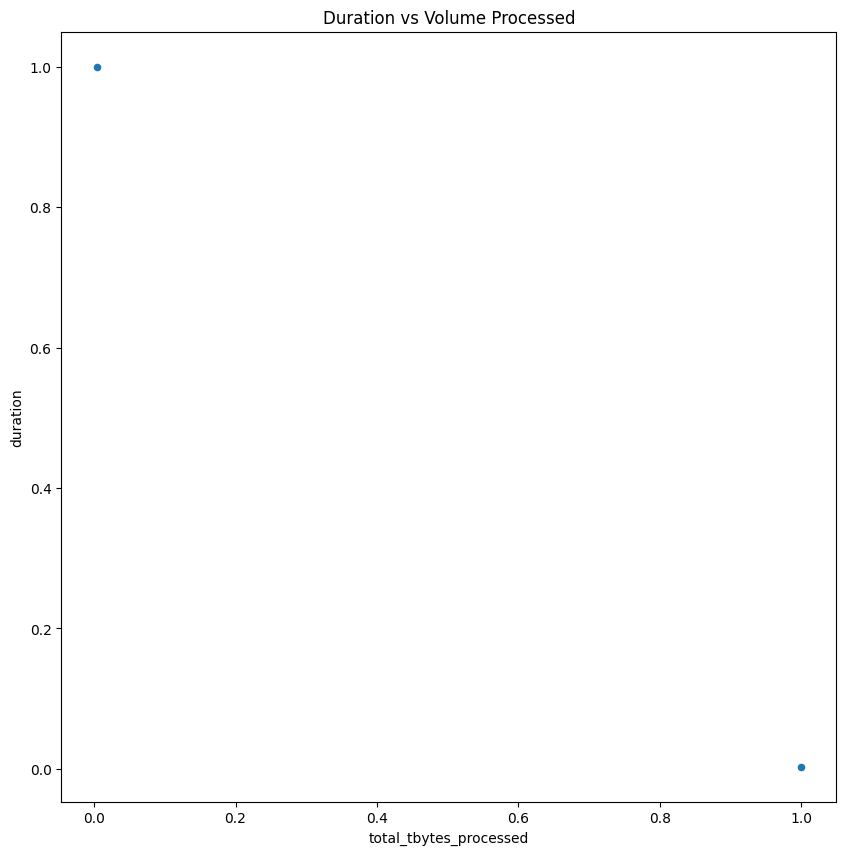

In [162]:
bq_duration.plot(kind = 'scatter'
                  ,figsize = (10,10)
                  ,x = 'total_tbytes_processed'
                  ,y = 'duration'
                  ,title='Duration vs Volume Processed')

**What did we find?**

The correlation between processing volume and query duration is approximately zero (0.003294), indicating no meaningful linear relationship between the amount of data processed and query execution time in this dataset.

This suggests that processing a larger volume of data does not necessarily result in longer query execution times.